In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import bjontegaard as bd

pd.set_option('display.max_columns', None)
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['axes.labelsize'] = 22

### My results (AHT-DCT)

In [ ]:
results_df = pd.read_csv("results.csv", header=0)
results_df = results_df[results_df["bpp"] > 0.1]

results_df.tail(20)

In [3]:
results_highres_df = pd.read_csv("results_highres.csv", header=0).sort_values(["arch", "model", "lmbda"])
results_highres_df = results_highres_df[results_highres_df["bpp"] > 0.1]

results_highres_df.head(50)

,arch,model,lmbda,test_date,bpp,psnr_iq,msssim_iq,psnr_amp,sqnr_amp,msssim_amp,mae_phase,mse_nrcs,enc_time,dec_time,total_kmac_per_px,enc_kmac_per_px,dec_kmac_per_px,ga_kmac_per_px,ha_kmac_per_px,gs_kmac_per_px,hs_kmac_per_px,total_params,energy_1,energy_2,energy_3,energy_4
24,PACT,g8alpha0.01,0.0625,20260402,0.465302,20.476471,0.805408,18.087464,7.984541,0.788115,1.052125,0.010877,0.332667,0.078914,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,0.346280,0.257438,0.159975,0.056247
26,PACT,g8alpha0.01,0.1250,20260402,0.925674,25.189848,0.940537,22.706459,12.571876,0.923588,0.626023,0.003988,0.338697,0.083624,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,1.754892,0.980088,0.634684,0.107554
27,PACT,g8alpha0.01,0.2500,20260403,1.410095,29.498780,0.982568,27.054981,17.343239,0.975672,0.362055,0.001771,0.332701,0.086311,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,6.457726,3.382966,2.033947,0.510939
28,PACT,g8alpha0.01,0.3750,20260403,1.731918,31.662281,0.991723,29.279787,20.204157,0.987474,0.255999,0.001267,0.373518,0.133022,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,14.862523,7.160670,4.572407,0.970402
29,PACT,g8alpha0.01,0.5000,20260403,1.959442,32.871116,0.994815,30.576849,22.143095,0.991950,0.204400,0.001056,0.337932,0.092534,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,27.282309,12.253016,7.457195,1.906380
30,PACT,g8alpha0.01,0.6225,20260403,2.134476,33.552336,0.996326,31.310996,23.506273,0.993964,0.173685,0.000999,0.327273,0.090326,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,43.697002,18.369883,10.725974,3.183356
31,PACT,g8alpha0.01,0.7500,20260403,2.304932,34.764829,0.997393,32.545030,25.066521,0.995827,0.148905,0.000764,0.331712,0.091912,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,70.027206,26.853668,16.996428,4.467964
23,PACT,g8alpha1.0,0.0008,20260402,0.545929,21.328327,0.837789,18.796325,8.609296,0.817086,0.963528,0.009074,0.334562,0.079855,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,0.457283,0.340956,0.211173,0.073383
25,PACT,g8alpha1.0,0.0017,20260402,1.012802,26.054910,0.952243,23.508982,13.380424,0.936716,0.567357,0.003359,0.340075,0.084775,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,2.254358,1.262826,0.811687,0.134568
18,PACT,g8alpha1.0,0.0033,20260402,1.428207,29.676542,0.982802,27.180337,17.402845,0.975561,0.354959,0.001711,0.331638,0.086437,20.3445,9.9745,10.37,9.495,0.4795,8.55,1.82,3836396,6.919589,3.641300,2.155662,0.549323


In [4]:
results_bench_df = pd.read_csv("results_bench.csv", header=0)
results_bench_df = results_bench_df[results_bench_df["bpp"] > 0.1]

results_bench_df.tail(20)

,codec,dataset,date,qp,bpp,mse_iq,psnr_iq,mse_amp,psnr_amp,sqnr_amp,mae_phase,mse_nrcs,encoding_time,decoding_time
0,JPEG2000,test,2026-03-31,3,2.6658,0.0007,31.5581,0.0013,28.9505,18.5132,0.3916,0.000596,0.536439,0.344256
1,JPEG2000,test,2026-03-31,4,1.9992,0.0020,27.0194,0.0036,24.4939,14.1789,0.6227,0.001618,0.530870,0.230861
2,JPEG2000,test,2026-03-31,6,1.3315,0.0049,23.0991,0.0088,20.5325,10.1844,0.9571,0.004221,0.530672,0.186690
3,JPEG2000,test,2026-03-31,15,0.5330,0.0145,18.3924,0.0288,15.4003,5.1646,1.5392,0.016798,0.532216,0.132241
4,HM,test,2026-03-31,27,2.7331,0.0002,36.5114,0.0004,33.5691,23.1869,0.2069,0.000244,10.281162,0.249836
5,HM,test,2026-03-31,32,2.0455,0.0006,31.9004,0.0013,29.0004,18.6219,0.3373,0.000777,9.799013,0.237238
6,HM,test,2026-03-31,37,1.4030,0.0019,27.1686,0.0037,24.3479,13.9776,0.5578,0.002508,8.921474,0.220978
7,HM,test,2026-03-31,42,0.7682,0.0060,22.1983,0.0118,19.2739,8.9464,0.9966,0.008003,7.327422,0.205440
8,VTM,test,2026-03-31,27,2.6424,0.0002,37.0876,0.0004,34.1613,23.7336,0.1953,0.000211,357.164426,0.314464
9,VTM,test,2026-03-31,32,1.9804,0.0006,32.5402,0.0011,29.6434,19.2451,0.3157,0.000635,313.785793,0.286379


# Ablation Study: Group Size

Model: g1 | BD-Rate: 0.00%
Model: g2 | BD-Rate: -0.21%
Model: g4 | BD-Rate: 1.11%
Model: g8 | BD-Rate: -0.14%
Model: g16 | BD-Rate: 0.72%
Model: g32 | BD-Rate: 1.52%


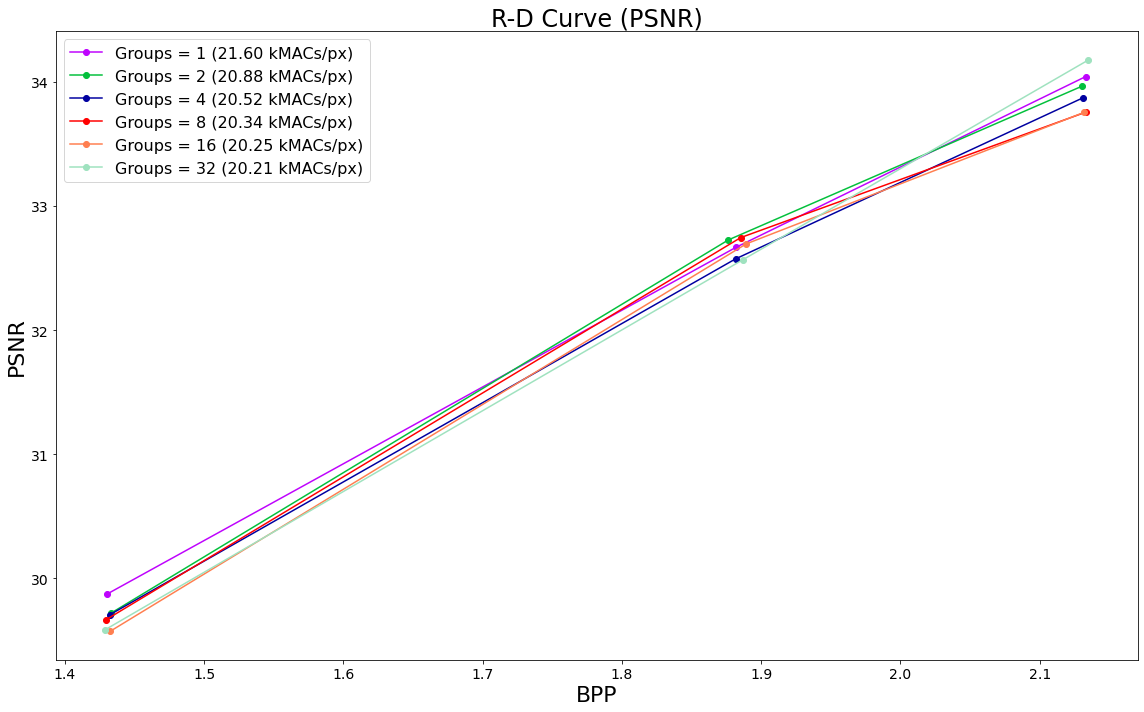

In [34]:
rd_data = {}
colors = ["#BE03FD", "#03C03C", "#0000A0", "#FF0000", "#FF7F50", "#9FE2BF"]
for model in ["g1", "g2", "g4", "g8", "g16", "g32"]:
    data = results_highres_df[(results_highres_df["arch"] == "PACTtest") & (results_highres_df["model"] == f"{model}alpha1.0")]
    rd_data[model] = {
        "bpp": data["bpp"].round(4).tolist(),
        "psnr": data["psnr_iq"].round(4).tolist(),
        "kmacs": data["total_kmac_per_px"].round(4).tolist()[0],
        "color": colors.pop(0) if colors else "#000000",
        "marker": "o",
        "linestyle": "solid",
    }

legend_labels = {
    "g1": f"Groups = 1 ({rd_data['g1']['kmacs']:.2f} kMACs/px)",
    "g2": f"Groups = 2 ({rd_data['g2']['kmacs']:.2f} kMACs/px)",
    "g4": f"Groups = 4 ({rd_data['g4']['kmacs']:.2f} kMACs/px)",
    "g8": f"Groups = 8 ({rd_data['g8']['kmacs']:.2f} kMACs/px)",
    "g16": f"Groups = 16 ({rd_data['g16']['kmacs']:.2f} kMACs/px)",
    "g32": f"Groups = 32 ({rd_data['g32']['kmacs']:.2f} kMACs/px)",
}

for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    psnr_test = rd_data[model]["psnr"]
    rate_anchor = rd_data["g1"]["bpp"]
    psnr_anchor = rd_data["g1"]["psnr"]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor,
        psnr_anchor,
        rate_test,
        psnr_test,
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_title("R-D Curve (PSNR)", fontsize=24)

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    ax.plot(bpp, psnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])

ax.set_xlabel("BPP", fontsize=22)
ax.set_ylabel("PSNR", fontsize=22)
ax.legend([legend_labels[key] for key in rd_data.keys()], fontsize=16)
plt.tight_layout()
plt.show()

# Benchmarking with G=8

SQNR BD-RATE
Model: jpeg2000 | BD-Rate: 52.01%
Model: hevc | BD-Rate: 8.28%
Model: vvc | BD-Rate: 0.00%
Model: elicdct | BD-Rate: -21.59%
Model: pactamp | BD-Rate: -17.93%

MAPE BD-RATE
Model: jpeg2000 | BD-Rate: 69.88%
Model: hevc | BD-Rate: 8.05%
Model: vvc | BD-Rate: 0.00%
Model: elicdct | BD-Rate: -20.92%
Model: pactamp | BD-Rate: -22.24%


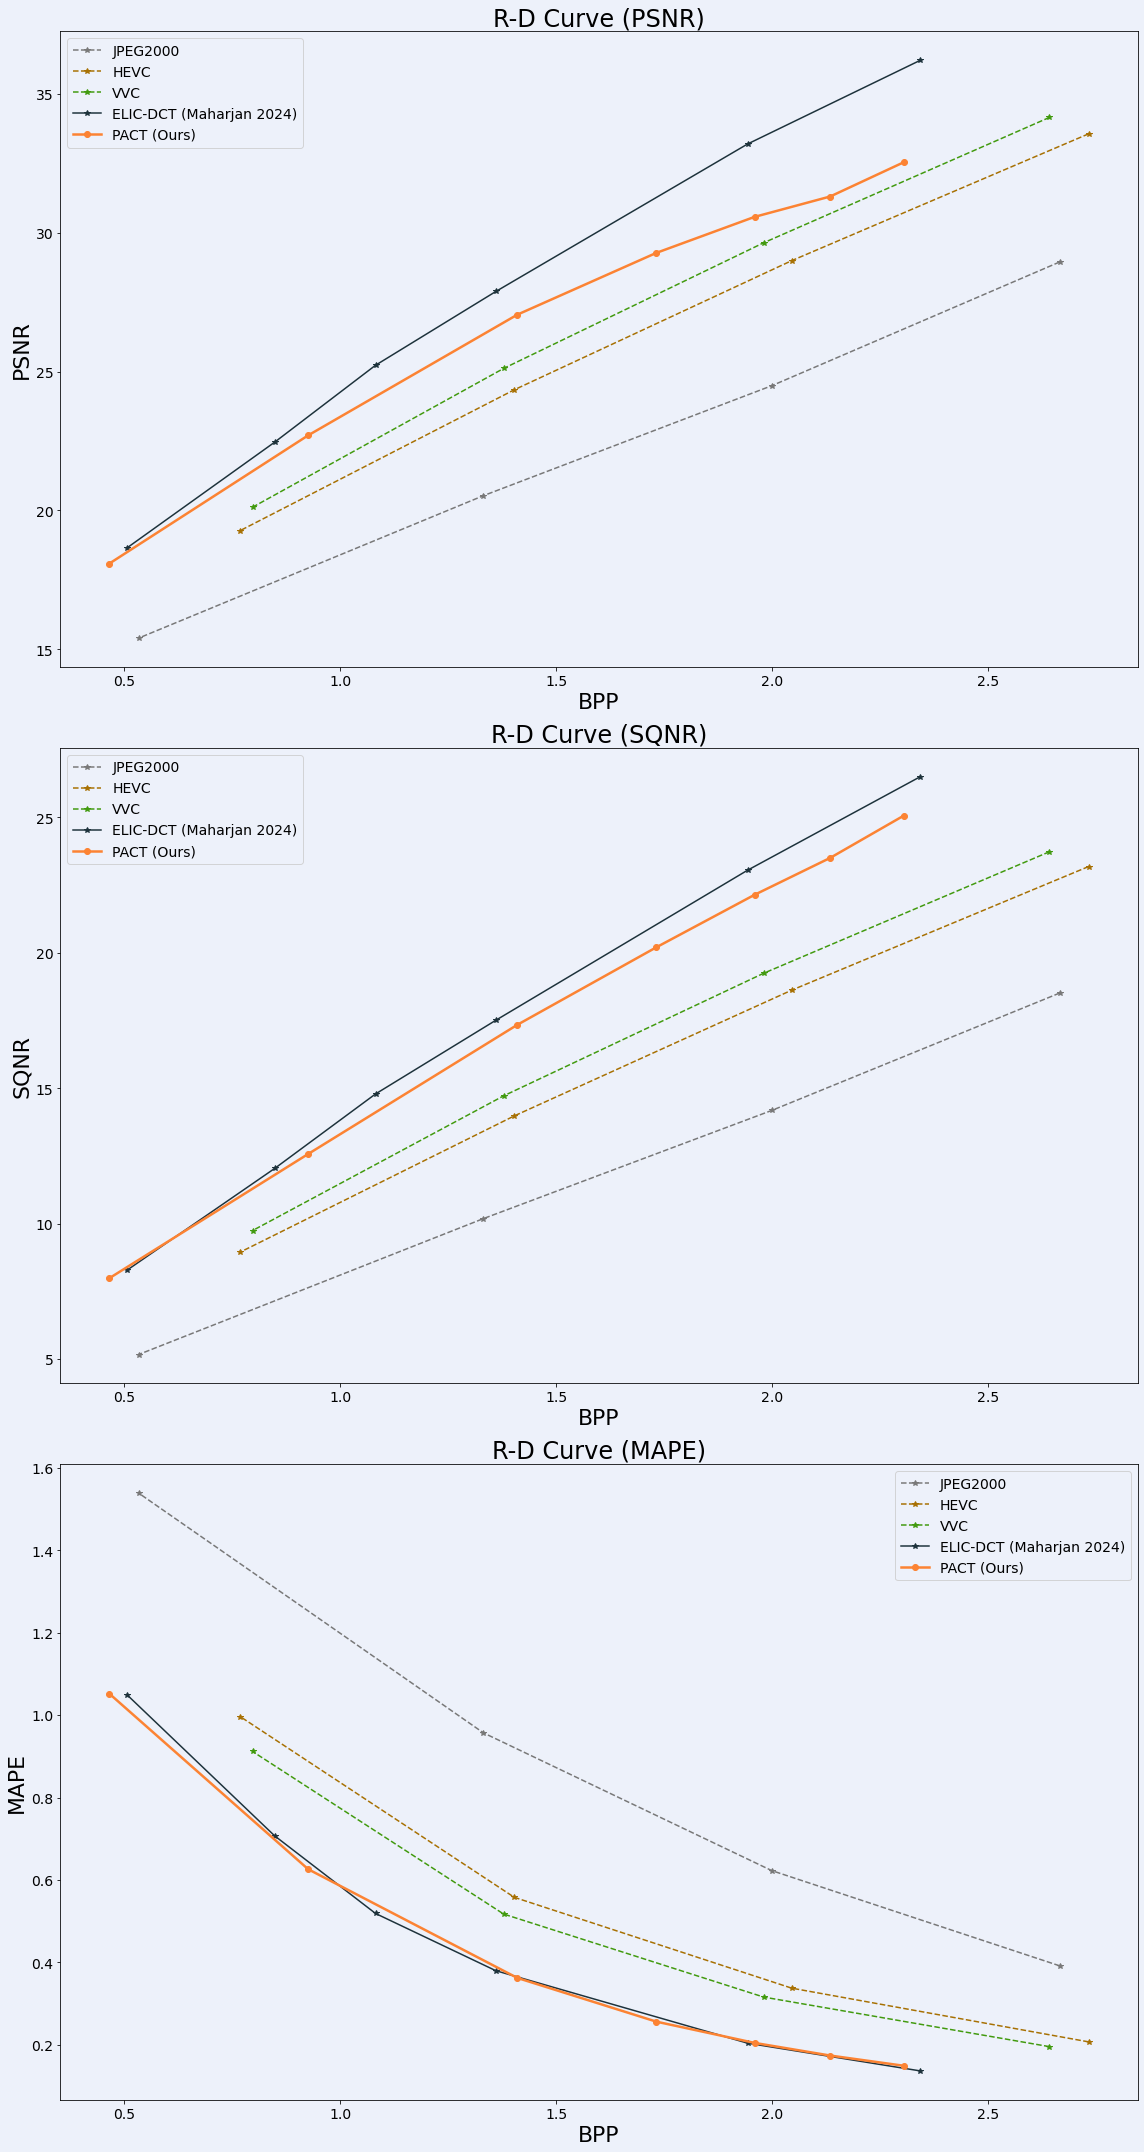

In [22]:
jpeg2000_hr_data = results_bench_df[results_bench_df["codec"] == "JPEG2000"]
hevc_hr_data = results_bench_df[results_bench_df["codec"] == "HM"]
vvc_hr_data = results_bench_df[results_bench_df["codec"] == "VTM"]
pactiq_hr_data = results_highres_df[(results_highres_df["arch"] == "PACT") & (results_highres_df["model"] == "g8alpha1.0")]
pactamp_hr_data = results_highres_df[(results_highres_df["arch"] == "PACT") & (results_highres_df["model"] == "g8alpha0.01")]

rd_data = {
    "jpeg2000": {
        "bpp": jpeg2000_hr_data["bpp"].round(4).tolist(),
        "psnr": jpeg2000_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": jpeg2000_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": jpeg2000_hr_data["mae_phase"].round(4).tolist(),
        "color": "#787878",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
    },
    "hevc": {
        "bpp": hevc_hr_data["bpp"].round(4).tolist(),
        "psnr": hevc_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": hevc_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": hevc_hr_data["mae_phase"].round(4).tolist(),
        "color": "#A77002",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
    },
    "vvc": {
        "bpp": vvc_hr_data["bpp"].round(4).tolist(),
        "psnr": vvc_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": vvc_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": vvc_hr_data["mae_phase"].round(4).tolist(),
        "color": "#419A0E",
        "marker": "*",
        "linestyle": "dashed",
        "linewidth": 1.5,
    },
    "elicdct": {
        "bpp":  [2.9640 , 2.7782 , 2.5324 , 2.3432 , 1.9434 , 1.3604 , 1.0817 , 0.8479 , 0.5069][3:],
        "psnr": [39.0820, 38.6299, 37.3533, 36.2189, 33.2039, 27.8906, 25.2319, 22.4584, 18.6599][3:],
        "sqnr": [30.6782, 29.6883, 27.9480, 26.5056, 23.0530, 17.5115, 14.7887, 12.0348, 8.2879][3:],
        "mape": [0.0833 , 0.0936 , 0.1150 , 0.1364 , 0.2037 , 0.3796 , 0.5186 , 0.7072 , 1.0487][3:],
        "color":"#1d323b",
        "marker": "*",
        "linestyle": "solid",
        "linewidth": 1.5,
    },
    # "pactiq": {
    #     "bpp": pactiq_hr_data["bpp"].round(4).tolist(),
    #     "psnr": pactiq_hr_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": pactiq_hr_data["sqnr_amp"].round(4).tolist(),
    #     "mape": pactiq_hr_data["mae_phase"].round(4).tolist(),
    #     "color": "#01b8aa",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    "pactamp": {
        "bpp": pactamp_hr_data["bpp"].round(4).tolist(),
        "psnr": pactamp_hr_data["psnr_amp"].round(4).tolist(),
        "sqnr": pactamp_hr_data["sqnr_amp"].round(4).tolist(),
        "mape": pactamp_hr_data["mae_phase"].round(4).tolist(),
        "color": "#FC8333",
        "marker": "o",
        "linestyle": "solid",
        "linewidth": 2.5,
    },
}

legend_labels = {
    "jpeg2000": "JPEG2000",
    "hevc": "HEVC",
    "vvc": "VVC",
    "elicdct": "ELIC-DCT (Maharjan 2024)",
    # "pactiq": "PACT (I/Q only)",
    "pactamp": "PACT (Ours)",
}

# SQNR BD-Rate
print("SQNR BD-RATE")
for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    psnr_test = rd_data[model]["sqnr"]
    rate_anchor = rd_data["vvc"]["bpp"]
    psnr_anchor = rd_data["vvc"]["sqnr"]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor, 
        psnr_anchor, 
        rate_test, 
        psnr_test, 
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

# MAPE BD-Rate
print("\nMAPE BD-RATE")
for model in rd_data.keys():
    rate_test = rd_data[model]["bpp"]
    mape_test = [-x for x in rd_data[model]["mape"]]
    rate_anchor = rd_data["vvc"]["bpp"]
    mape_anchor = [-x for x in rd_data["vvc"]["mape"]]
    rd_data[model]["bd_rate"] = bd.bd_rate(
        rate_anchor, 
        mape_anchor, 
        rate_test, 
        mape_test, 
        method='akima',
        require_matching_points=False,
    )
    print(f"Model: {model} | BD-Rate: {rd_data[model]['bd_rate']:.2f}%")

# Make 3 subplots for PSNR, SQNR, and MAPE
fig, ax = plt.subplots(3, 1, figsize=(16, 30))
bg_color = "#edf1fa"

ax[0].set_title("R-D Curve (PSNR)", fontsize=24)
ax[1].set_title("R-D Curve (SQNR)", fontsize=24)
ax[2].set_title("R-D Curve (MAPE)", fontsize=24)

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    sqnr = rd_data[model]["sqnr"]
    mape = rd_data[model]["mape"]

    ax[0].plot(bpp, psnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])
    ax[1].plot(bpp, sqnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])
    ax[2].plot(bpp, mape, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"], linewidth=rd_data[model]["linewidth"])

ax[0].set_xlabel("BPP", fontsize=22)
ax[0].set_ylabel("PSNR", fontsize=22)
ax[0].legend([legend_labels[key] for key in rd_data.keys()], facecolor=bg_color)
ax[1].set_xlabel("BPP", fontsize=22)
ax[1].set_ylabel("SQNR", fontsize=22)
ax[1].legend([legend_labels[key] for key in rd_data.keys()], facecolor=bg_color)

# extent = ax[1].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
# fig.savefig("rd_sqnr.png", bbox_inches=extent)

ax[2].set_xlabel("BPP", fontsize=22)
ax[2].set_ylabel("MAPE", fontsize=22)
ax[2].legend([legend_labels[key] for key in rd_data.keys()], facecolor=bg_color)
fig.set_facecolor(bg_color)
ax[0].set_facecolor(bg_color)
ax[1].set_facecolor(bg_color)
ax[2].set_facecolor(bg_color)
plt.tight_layout()
plt.show()

### Data from Maharjan 2024 (ELIC-DCT)

In [15]:
rd_data = {
    # JPEG2000 (lowest BPP not shown in paper)
    "jpeg2000": {
        "bpp":  [2.6647 , 1.999  , 1.5992 , 0.9996 , 0.5323],
        "psnr": [28.925 , 24.4725, 22.2939, 18.6632, 15.3867],
        "sqnr": [18.4845, 14.1511, 11.9136, 8.3596 , 5.1653],
        "mape": [0.3918 , 0.6234 , 0.8121 , 1.1672 , 1.5330],
        "color":"#01b8aa",
        "marker": "^",
        "linestyle": "dashed",
    },
    # HEVC
    "hevc": {
        "bpp":  [2.8405 , 2.5788 , 1.9839 , 1.4525 , 0.9826 ],
        "psnr": [33.1111, 31.5369, 27.8776, 24.1401, 20.6104],
        "sqnr": [22.6497, 21.0718, 17.4426, 13.7223, 10.2396],
        "mape": [0.2195 , 0.2593 , 0.3812 , 0.5717 , 0.8370],
        "color":"#003f5c",
        "marker": "d",
        "linestyle": "dashed",
    },
    # VVC (lowest BPP not shown in paper)
    "vvc": {
        "bpp":  [2.8008 , 2.5111 , 1.98   , 1.4989 , 0.9148 , 0.5456 ],
        "psnr": [34.4543, 32.8780, 29.3566, 25.9315, 21.1603, 17.3979],
        "sqnr": [23.9722, 22.4221, 18.9250, 15.5249, 10.7797, 7.0912],
        "mape": [0.1867 , 0.2199 , 0.3190 , 0.4632 , 0.7914 , 1.1828],
        "color":"#9F2B68",
        "marker": "s",
        "linestyle": "dashed",
    },
    # LearnedIQ (Maharjan 2023)
    "learnediq": {
        "bpp":  [2.8405 , 2.5788 , 1.9839 , 1.4525 , 0.9826 ],
        "psnr": [34.3395, 32.9682, 29.4298, 25.3870, 21.5924],
        "sqnr": [23.9356, 22.5431, 18.9904, 14.9526, 11.1809],
        "mape": [0.1894 , 0.2232 , 0.3366 , 0.5202 , 0.7773],
        "color":"#65AD5E",
        "marker": "P",
        "linestyle": "dashed",
    },
    # ELIC-DCT (Maharjan 2024)
    "elicdct": {
        "bpp":  [2.9640 , 2.7782 , 2.5324 , 2.3432 , 1.9434 , 1.3604 ],
        "psnr": [39.0820, 38.6299, 37.3533, 36.2189, 33.2039, 27.8906],
        "sqnr": [30.6782, 29.6883, 27.9480, 26.5056, 23.0530, 17.5115],
        "mape": [0.0833 , 0.0936 , 0.1150 , 0.1364 , 0.2037 , 0.3796 ],
        "color":"#ed553b",
        "marker": "*",
        "linestyle": "dashed",
    },
    # VVC (test run)
    "vvc_test": {
        "bpp":  [2.6424026489257812, 1.9804115295410156, 1.3783226013183594, 0.7968597412109375],
        "psnr": [34.16133261181379, 29.643372360672803, 25.11676455873928, 20.116903173267527],
        "sqnr": [0, 0, 0, 0],
        "mape": [0, 0, 0, 0],
        "color":"#66FF00",
        "marker": "*",
        "linestyle": "dashed",
    },
    # HEVC (test run)
    "hevc_test": {
        "bpp":  [2.7330551147460938, 2.0455093383789062, 1.4030494689941406, 0.7681961059570312],
        "psnr": [33.56907014143184, 29.000359417029383, 24.347895303037514, 19.27389649617288],
        "sqnr": [0, 0, 0, 0],
        "mape": [0, 0, 0, 0],
        "color":"#FF0000",
        "marker": "*",
        "linestyle": "dashed",
    },
}

### RD-Curve: AHT vs. codecs in Maharjan 2024

In [16]:
# dct_hr_data = results_highres_df[results_highres_df["model"] == "DCT-ls-a5"]
# rd_data["aht_dct_hr"] = {
#     "bpp": dct_hr_data["bpp"].round(4).tolist(),
#     "psnr": dct_hr_data["psnr_amp"].round(4).tolist(),
#     "sqnr": dct_hr_data["sqnr_amp"].round(4).tolist(),
#     "mape": dct_hr_data["mae_phase"].round(4).tolist(),
#     "color": "#FF0000",
#     "marker": "o",
#     "linestyle": "solid",
# }

pconv4_hr_data = results_highres_df[results_highres_df["model"] == "DCT-pconv4"]
rd_data["aht_pconv4_hr"] = {
    "bpp": pconv4_hr_data["bpp"].round(4).tolist(),
    "psnr": pconv4_hr_data["psnr_amp"].round(4).tolist(),
    "sqnr": pconv4_hr_data["sqnr_amp"].round(4).tolist(),
    "mape": pconv4_hr_data["mae_phase"].round(4).tolist(),
    "color": "#BE03FD",
    "marker": "o",
    "linestyle": "solid",
}

# pconv7_hr_data = results_highres_df[results_highres_df["model"] == "DCT-pconv7"]
# rd_data["aht_pconv7_hr"] = {
#     "bpp": pconv7_hr_data["bpp"].round(4).tolist(),
#     "psnr": pconv7_hr_data["psnr_amp"].round(4).tolist(),
#     "sqnr": pconv7_hr_data["sqnr_amp"].round(4).tolist(),
#     "mape": pconv7_hr_data["mae_phase"].round(4).tolist(),
#     "color": "#FF0000",
#     "marker": "o",
#     "linestyle": "solid",
# }

legend_labels = {
    "jpeg2000": "JPEG2000",
    "hevc": "HEVC",
    "learnediq": "LearnedIQ (Maharjan 2023)",
    "vvc": "VVC",
    "elicdct": "ELIC-DCT (Maharjan 2024)",
    "aht_dct_hr": "AHT-DCT (Ours)",
    "aht_pconv4_hr": "AHT-DCT (Ours)",
    "aht_pconv7_hr": "AHT-DCT I/Q Direct (Ours)",
    "vvc_test": "VVC (Test)",
    "hevc_test": "HEVC (Test)",
}

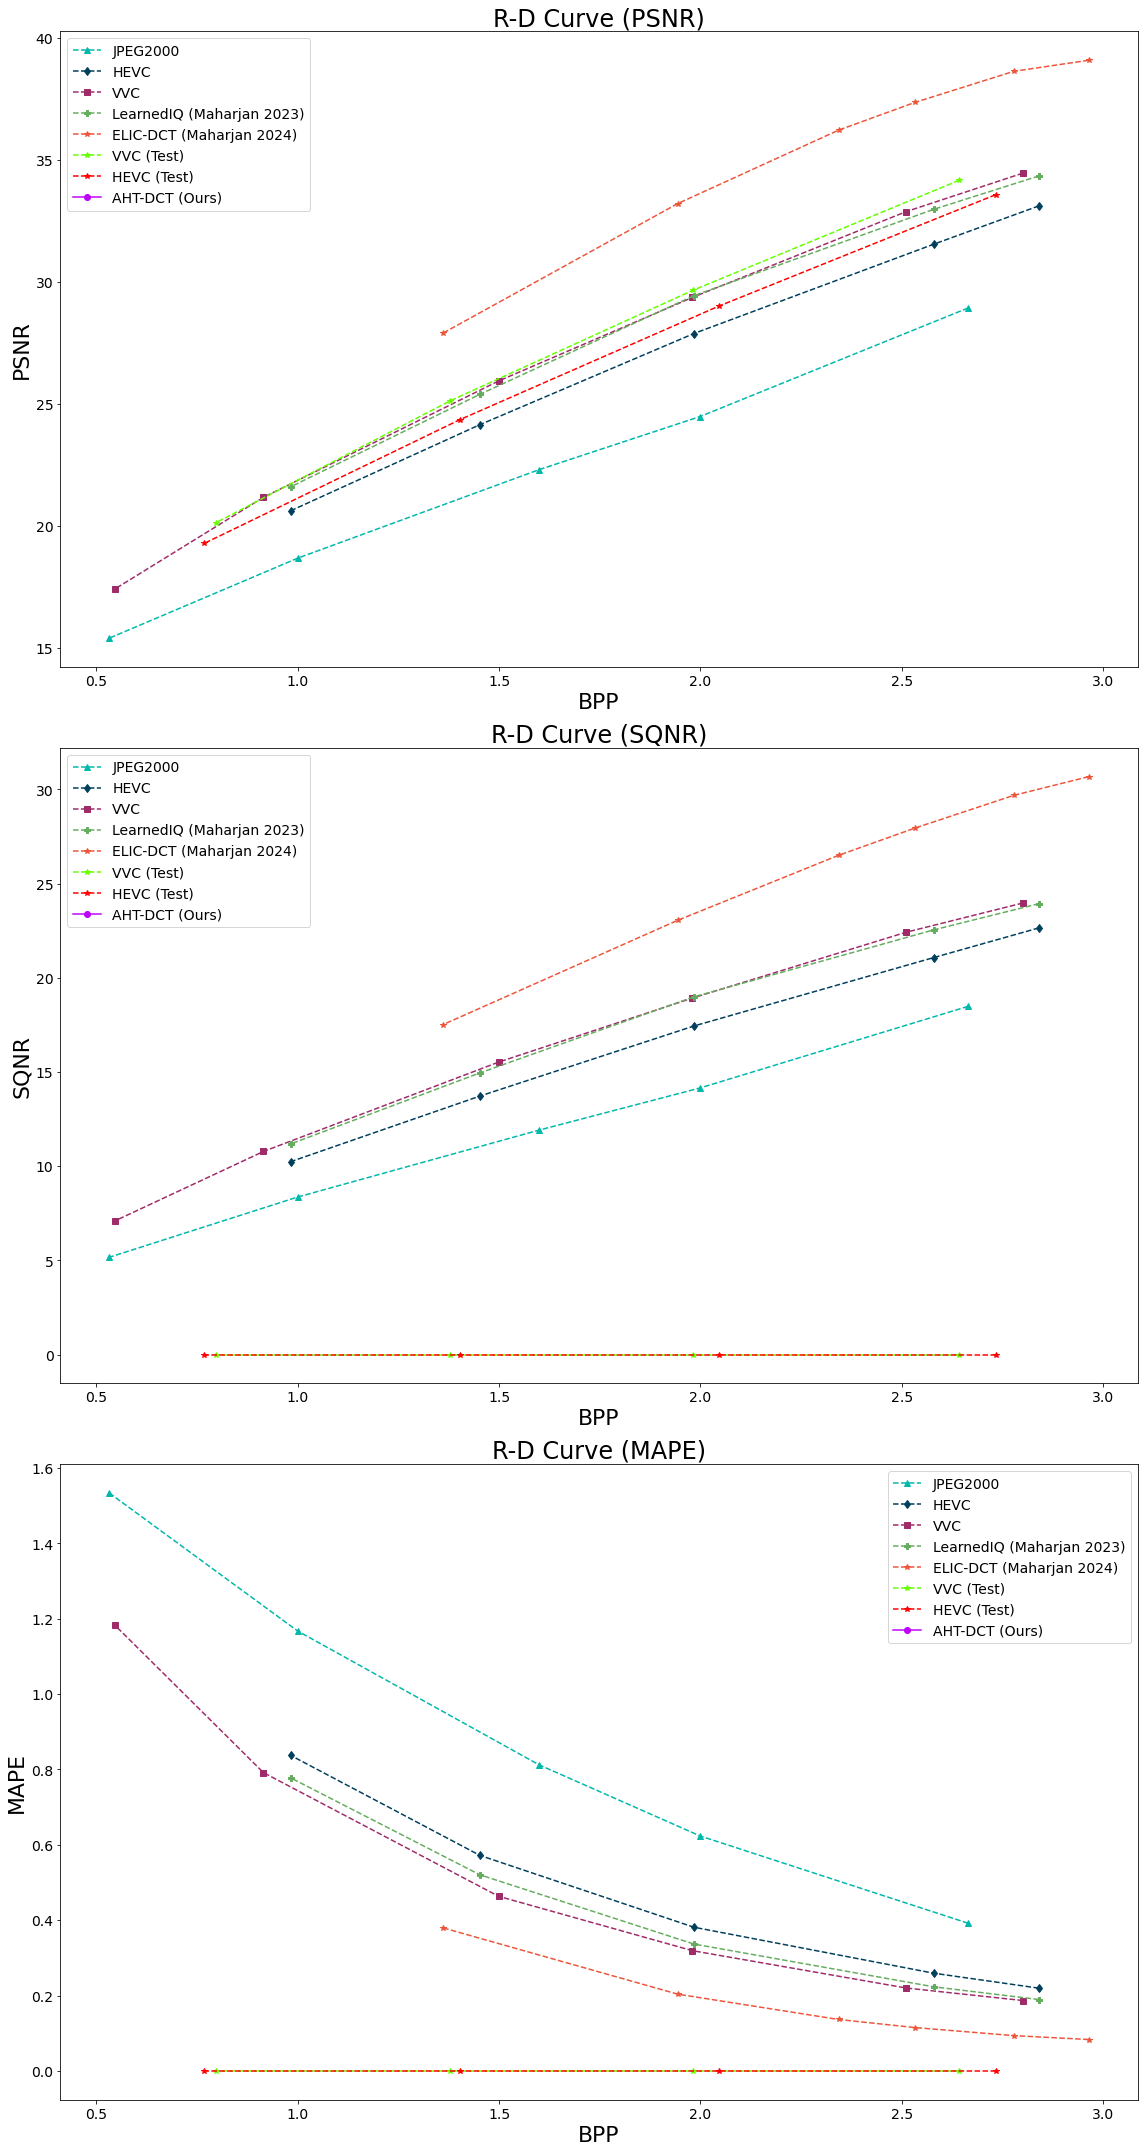

In [ ]:
# Make 3 subplots for PSNR, SQNR, and MAPE
fig, ax = plt.subplots(3, 1, figsize=(16, 30))

ax[0].set_title("R-D Curve (PSNR)", fontsize=24)
ax[1].set_title("R-D Curve (SQNR)", fontsize=24)
ax[2].set_title("R-D Curve (MAPE)", fontsize=24)

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    sqnr = rd_data[model]["sqnr"]
    mape = rd_data[model]["mape"]

    ax[0].plot(bpp, psnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])
    ax[1].plot(bpp, sqnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])
    ax[2].plot(bpp, mape, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])

ax[0].set_xlabel("BPP", fontsize=22)
ax[0].set_ylabel("PSNR", fontsize=22)
ax[0].legend([legend_labels[key] for key in rd_data.keys()])
ax[1].set_xlabel("BPP", fontsize=22)
ax[1].set_ylabel("SQNR", fontsize=22)
ax[1].legend([legend_labels[key] for key in rd_data.keys()])
ax[2].set_xlabel("BPP", fontsize=22)
ax[2].set_ylabel("MAPE", fontsize=22)
ax[2].legend([legend_labels[key] for key in rd_data.keys()])
plt.tight_layout()
plt.show()

In [18]:
baseline_data = results_df[results_df["model"] == "baseline"]
dct_data = results_df[results_df["model"] == "DCT-ls-a5"]
# pconv1_data = results_df[results_df["model"] == "DCT-pconv1"]
# pconv2_data = results_df[results_df["model"] == "DCT-pconv2"]
# pconv3_data = results_df[results_df["model"] == "DCT-pconv3"]
# losstesting_data = results_df[results_df["model"] == "losstesting"]
# losstesting_alpha_data = results_df[(results_df["model"].str.contains("alpha")) & (results_df["bpp"] > 0.1)]
pconv4_data = results_df[results_df["model"] == "DCT-pconv4"]
# pconv5_data = results_df[results_df["model"] == "DCT-pconv5"]
# pconv6_data = results_df[results_df["model"] == "DCT-pconv6"]
# pconv7_data = results_df[results_df["model"] == "DCT-pconv7"]

gconv0_data = results_df[results_df["model"] == "DCT-gconv0"]
gconv1_data = results_df[results_df["model"] == "DCT-gconv1"]
gconv2_data = results_df[results_df["model"] == "DCT-gconv2"]
gconv3_data = results_df[results_df["model"] == "DCT-gconv3"]
gconv4_data = results_df[results_df["model"] == "DCT-gconv4"]

rd_data = {
    # ELIC-DCT (Maharjan 2024)
    "elicdct": {
        "bpp":  [1.1671, 1.7363, 2.1235, 2.3037, 2.5415, 2.7217],
        "psnr": [28.1762, 33.6472, 36.9725, 38.3164, 39.9020, 40.7312],
        "sqnr": [15.2894, 20.8694, 24.4501, 25.9394, 27.7761, 28.8573],
        "mape": [0.5209, 0.2830, 0.1885, 0.1594, 0.1289, 0.1132],
        "color":"#ed553b",
        "marker": "*",
        "linestyle": "dashed",
    },
    "aht_baseline": {
        "bpp": baseline_data["bpp"].round(4).tolist(),
        "psnr": baseline_data["psnr_amp"].round(4).tolist(),
        "sqnr": baseline_data["sqnr_amp"].round(4).tolist(),
        "mape": baseline_data["mae_phase"].round(4).tolist(),
        "color": "#1f77b4",
        "marker": "o",
        "linestyle": "solid",
    },
    # "aht_dct": {
    #     "bpp": dct_data["bpp"].round(4).tolist(),
    #     "psnr": dct_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": dct_data["sqnr_amp"].round(4).tolist(),
    #     "mape": dct_data["mae_phase"].round(4).tolist(),
        # "color": "#1f77b4",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_pconv1": {
    #     "bpp": pconv1_data["bpp"].round(4).tolist(),
    #     "psnr": pconv1_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": pconv1_data["sqnr_amp"].round(4).tolist(),
    #     "mape": pconv1_data["mae_phase"].round(4).tolist(),
    #     "color": "#FF2400",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_pconv2": {
    #     "bpp": pconv2_data["bpp"].round(4).tolist(),
    #     "psnr": pconv2_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": pconv2_data["sqnr_amp"].round(4).tolist(),
    #     "mape": pconv2_data["mae_phase"].round(4).tolist(),
    #     "color": "#BE03FD",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_pconv3": {
    #     "bpp": pconv3_data["bpp"].round(4).tolist(),
    #     "psnr": pconv3_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": pconv3_data["sqnr_amp"].round(4).tolist(),
    #     "mape": pconv3_data["mae_phase"].round(4).tolist(),
    #     "color": "#66FF00",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_losstesting": {
    #     "bpp": losstesting_data["bpp"].round(4).tolist(),
    #     "psnr": losstesting_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": losstesting_data["sqnr_amp"].round(4).tolist(),
    #     "mape": losstesting_data["mae_phase"].round(4).tolist(),
    #     "color": "#BE03FD",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_losstesting_alpha": {
    #     "bpp": losstesting_alpha_data["bpp"].round(4).tolist(),
    #     "psnr": losstesting_alpha_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": losstesting_alpha_data["sqnr_amp"].round(4).tolist(),
    #     "mape": losstesting_alpha_data["mae_phase"].round(4).tolist(),
    #     "color": "#BE03FD",
    #     "marker": "o",
    #     "linestyle": "None",
    # },
    "aht_dct_pconv4": {
        "bpp": pconv4_data["bpp"].round(4).tolist(),
        "psnr": pconv4_data["psnr_amp"].round(4).tolist(),
        "sqnr": pconv4_data["sqnr_amp"].round(4).tolist(),
        "mape": pconv4_data["mae_phase"].round(4).tolist(),
        "color": "#BE03FD",
        "marker": "o",
        "linestyle": "solid",
    },
    # "aht_dct_pconv5": {
    #     "bpp": pconv5_data["bpp"].round(4).tolist(),
    #     "psnr": pconv5_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": pconv5_data["sqnr_amp"].round(4).tolist(),
    #     "mape": pconv5_data["mae_phase"].round(4).tolist(),
    #     "color": "#FF2400",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_pconv6": {
    #     "bpp": pconv6_data["bpp"].round(4).tolist(),
    #     "psnr": pconv6_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": pconv6_data["sqnr_amp"].round(4).tolist(),
    #     "mape": pconv6_data["mae_phase"].round(4).tolist(),
    #     "color": "#FF2400",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_pconv7": {
    #     "bpp": pconv7_data["bpp"].round(4).tolist(),
    #     "psnr": pconv7_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": pconv7_data["sqnr_amp"].round(4).tolist(),
    #     "mape": pconv7_data["mae_phase"].round(4).tolist(),
    #     "color": "#FF2400",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_gconv0": {
    #     "bpp": gconv0_data["bpp"].round(4).tolist(),
    #     "psnr": gconv0_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": gconv0_data["sqnr_amp"].round(4).tolist(),
    #     "mape": gconv0_data["mae_phase"].round(4).tolist(),
    #     "color": "#FF2400",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_gconv1": {
    #     "bpp": gconv1_data["bpp"].round(4).tolist(),
    #     "psnr": gconv1_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": gconv1_data["sqnr_amp"].round(4).tolist(),
    #     "mape": gconv1_data["mae_phase"].round(4).tolist(),
    #     "color": "#BA8E23",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_gconv2": {
    #     "bpp": gconv2_data["bpp"].round(4).tolist(),
    #     "psnr": gconv2_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": gconv2_data["sqnr_amp"].round(4).tolist(),
    #     "mape": gconv2_data["mae_phase"].round(4).tolist(),
    #     "color": "#a3f3a6",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_gconv3": {
    #     "bpp": gconv3_data["bpp"].round(4).tolist(),
    #     "psnr": gconv3_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": gconv3_data["sqnr_amp"].round(4).tolist(),
    #     "mape": gconv3_data["mae_phase"].round(4).tolist(),
    #     "color": "#1a355b",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
    # "aht_dct_gconv4": {
    #     "bpp": gconv4_data["bpp"].round(4).tolist(),
    #     "psnr": gconv4_data["psnr_amp"].round(4).tolist(),
    #     "sqnr": gconv4_data["sqnr_amp"].round(4).tolist(),
    #     "mape": gconv4_data["mae_phase"].round(4).tolist(),
    #     "color": "#92b938",
    #     "marker": "o",
    #     "linestyle": "solid",
    # },
}

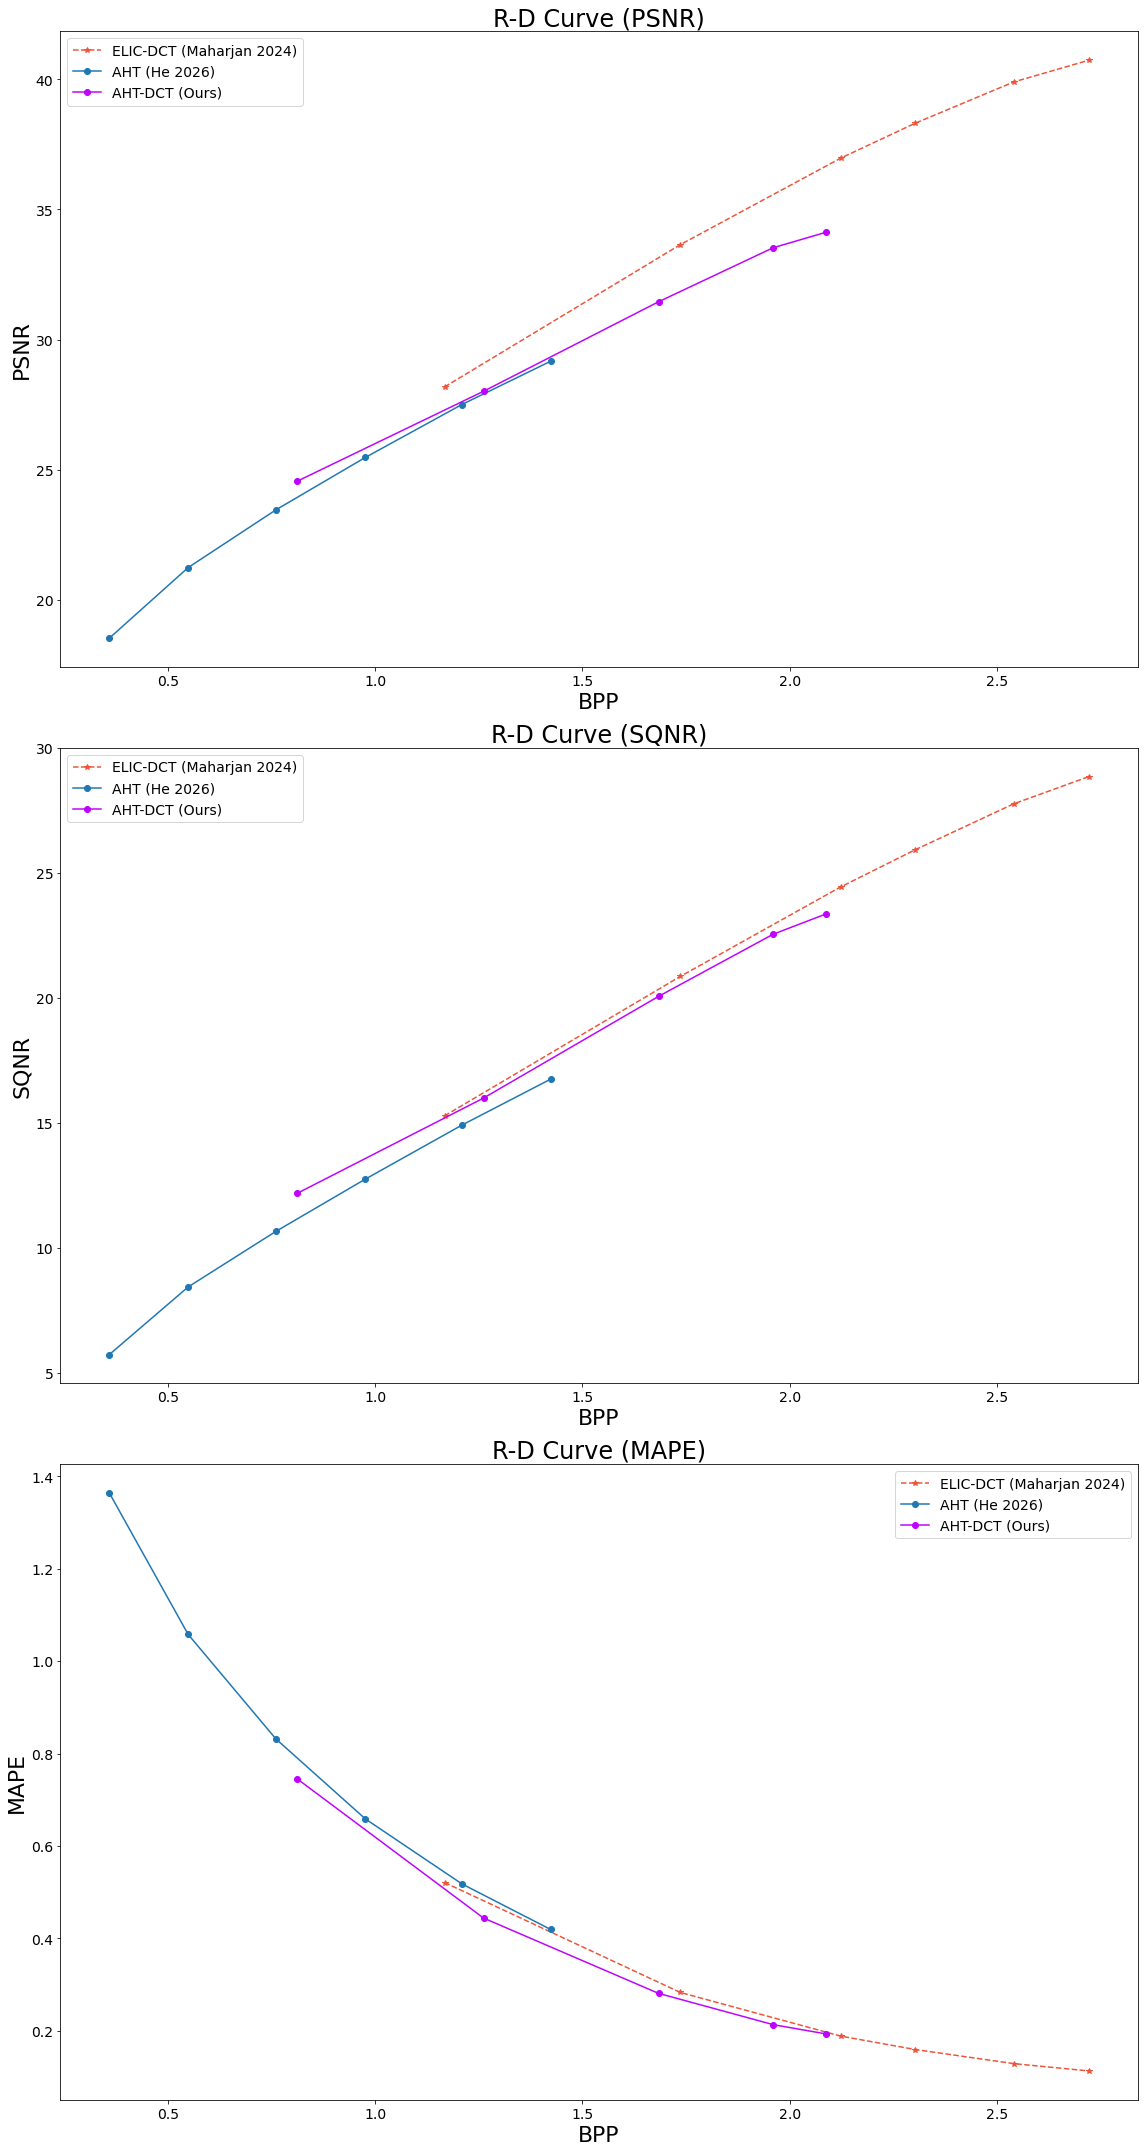

In [19]:
legend_labels = {
    "elicdct": "ELIC-DCT (Maharjan 2024)",
    "aht_baseline": "AHT (He 2026)",
    "aht_dct": "AHT-DCT (Ours)",
    "aht_dct_pconv1": "AHT-pconv1",
    "aht_dct_pconv2": "AHT-pconv2",
    "aht_dct_pconv3": "AHT-DCT (More Channels)",
    "aht_losstesting": "AHT (Loss Testing)",
    "aht_losstesting_alpha": "AHT (Loss Testing - Alpha)",
    "aht_dct_pconv4": "AHT-DCT (Ours)",
    "aht_dct_pconv5": "AHT-DCT (Uneven Groups)",
    "aht_dct_pconv6": "AHT-DCT (T-PConvEA)",
    "aht_dct_pconv7": "AHT-DCT (I/Q Direct)",
    "aht_dct_gconv0": "aht_dct_gconv0",
    "aht_dct_gconv1": "aht_dct_gconv1",
    "aht_dct_gconv2": "aht_dct_gconv2",
    "aht_dct_gconv3": "aht_dct_gconv3",
    "aht_dct_gconv4": "aht_dct_gconv4",
}

fig, ax = plt.subplots(3, 1, figsize=(16, 30))

ax[0].set_title("R-D Curve (PSNR)", fontsize=24)
ax[1].set_title("R-D Curve (SQNR)", fontsize=24)
ax[2].set_title("R-D Curve (MAPE)", fontsize=24)

for i, model in enumerate(rd_data.keys()):
    bpp = rd_data[model]["bpp"]
    psnr = rd_data[model]["psnr"]
    sqnr = rd_data[model]["sqnr"]
    mape = rd_data[model]["mape"]

    ax[0].plot(bpp, psnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])
    ax[1].plot(bpp, sqnr, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])
    ax[2].plot(bpp, mape, label=model, marker=rd_data[model]["marker"], linestyle=rd_data[model]["linestyle"], color=rd_data[model]["color"])

ax[0].set_xlabel("BPP", fontsize=22)
ax[0].set_ylabel("PSNR", fontsize=22)
ax[0].legend([legend_labels[key] for key in rd_data.keys()])
ax[1].set_xlabel("BPP", fontsize=22)
ax[1].set_ylabel("SQNR", fontsize=22)
ax[1].legend([legend_labels[key] for key in rd_data.keys()])
ax[2].set_xlabel("BPP", fontsize=22)
ax[2].set_ylabel("MAPE", fontsize=22)
ax[2].legend([legend_labels[key] for key in rd_data.keys()])
plt.tight_layout()
plt.show()

In [6]:
results_df.loc[results_df["model"].str.contains("gconv"), ["model", "bpp", "psnr_amp", "sqnr_amp", "mae_phase", "total_kmac_per_px"]]

,model,bpp,psnr_amp,sqnr_amp,mae_phase,total_kmac_per_px
70,DCT-gconv0,1.566637,30.667706,18.868843,0.331678,29.1605
71,DCT-gconv1,1.596491,30.925490,19.192676,0.329640,29.1605
72,DCT-gconv2,1.581503,30.784836,19.053841,0.346497,29.5605
73,DCT-gconv3,1.551410,30.376304,18.505112,0.346215,29.5605
74,DCT-gconv4,1.593437,30.953785,19.224316,0.328542,29.7205


# Amplitude PSNR

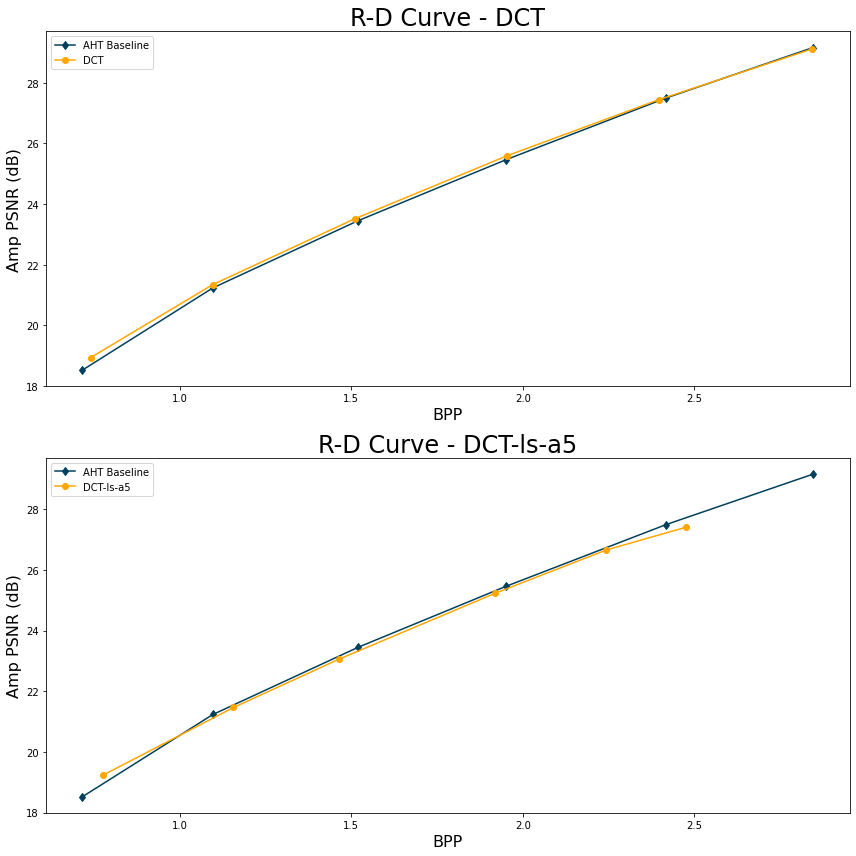

In [12]:
models = ["DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(len(models), 1, figsize=(12, len(models)*6))

for i, model in enumerate(models):
    baseline_data = results_df[results_df["model"] == "baseline"]
    exp_data = results_df[results_df["model"] == model]
    ax[i].plot(baseline_data["bpp"], baseline_data["psnr_amp"], label="AHT Baseline", marker="d", color="#003f5c")
    ax[i].plot(exp_data["bpp"], exp_data["psnr_amp"], label=model, marker="o", color="#ffa600")
    ax[i].set_xlabel("BPP", fontsize=16)
    ax[i].set_ylabel("Amp PSNR (dB)", fontsize=16)
    ax[i].set_title(f"R-D Curve - {model}", fontsize=24)
    ax[i].legend()

plt.tight_layout()
plt.show()

# Amplitude SQNR

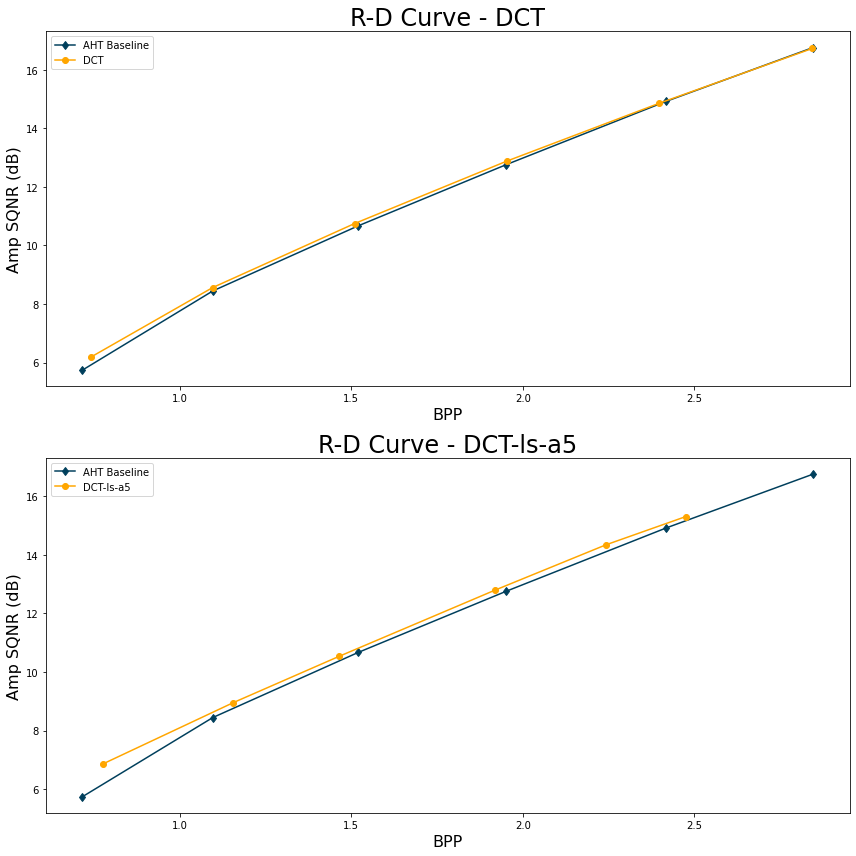

In [13]:

models = ["DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(len(models), 1, figsize=(12, len(models)*6))

for i, model in enumerate(models):
    baseline_data = results_df[results_df["model"] == "baseline"]
    exp_data = results_df[results_df["model"] == model]
    ax[i].plot(baseline_data["bpp"], baseline_data["sqnr_amp"], label="AHT Baseline", marker="d", color="#003f5c")
    ax[i].plot(exp_data["bpp"], exp_data["sqnr_amp"], label=model, marker="o", color="#ffa600")
    ax[i].set_xlabel("BPP", fontsize=16)
    ax[i].set_ylabel("Amp SQNR (dB)", fontsize=16)
    ax[i].set_title(f"R-D Curve - {model}", fontsize=24)
    ax[i].legend()

plt.tight_layout()
plt.show()

# Phase MAE

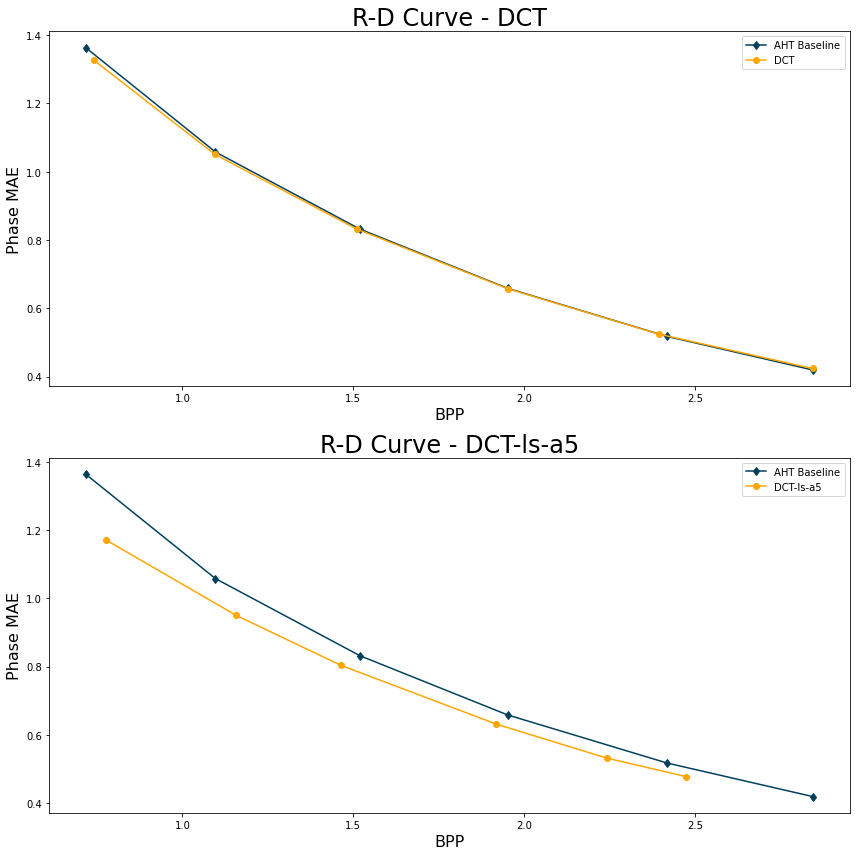

In [14]:
models = ["DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(len(models), 1, figsize=(12, len(models)*6))

for i, model in enumerate(models):
    baseline_data = results_df[results_df["model"] == "baseline"]
    exp_data = results_df[results_df["model"] == model]
    ax[i].plot(baseline_data["bpp"], baseline_data["mae_phase"], label="AHT Baseline", marker="d", color="#003f5c")
    ax[i].plot(exp_data["bpp"], exp_data["mae_phase"], label=model, marker="o", color="#ffa600")
    ax[i].set_xlabel("BPP", fontsize=16)
    ax[i].set_ylabel("Phase MAE", fontsize=16)
    ax[i].set_title(f"R-D Curve - {model}", fontsize=24)
    ax[i].legend()

plt.tight_layout()
plt.show()

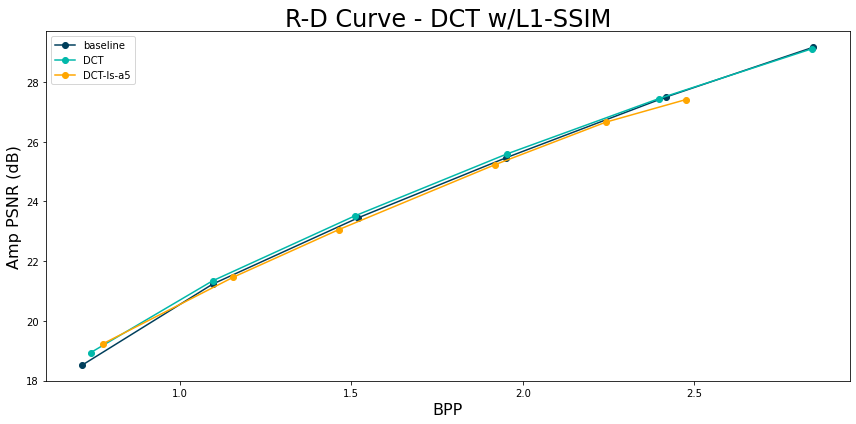

In [18]:
models = ["baseline", "DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ["#003f5c", "#01b8aa", "#ffa600"]

for i, model in enumerate(models):
    exp_data = results_df[results_df["model"] == model]
    ax.plot(exp_data["bpp"], exp_data["psnr_amp"], label=model, marker="o", color=colors[i])
    ax.set_xlabel("BPP", fontsize=16)
    ax.set_ylabel("Amp PSNR (dB)", fontsize=16)
    ax.set_title("R-D Curve - DCT w/L1-SSIM", fontsize=24)
    ax.legend()

plt.tight_layout()
plt.show()

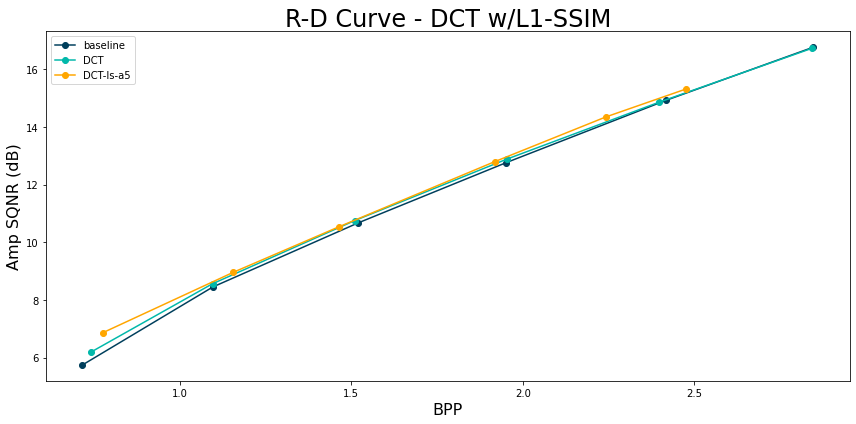

In [19]:
models = ["baseline", "DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ["#003f5c", "#01b8aa", "#ffa600"]

for i, model in enumerate(models):
    exp_data = results_df[results_df["model"] == model]
    ax.plot(exp_data["bpp"], exp_data["sqnr_amp"], label=model, marker="o", color=colors[i])
    ax.set_xlabel("BPP", fontsize=16)
    ax.set_ylabel("Amp SQNR (dB)", fontsize=16)
    ax.set_title("R-D Curve - DCT w/L1-SSIM", fontsize=24)
    ax.legend()

plt.tight_layout()
plt.show()

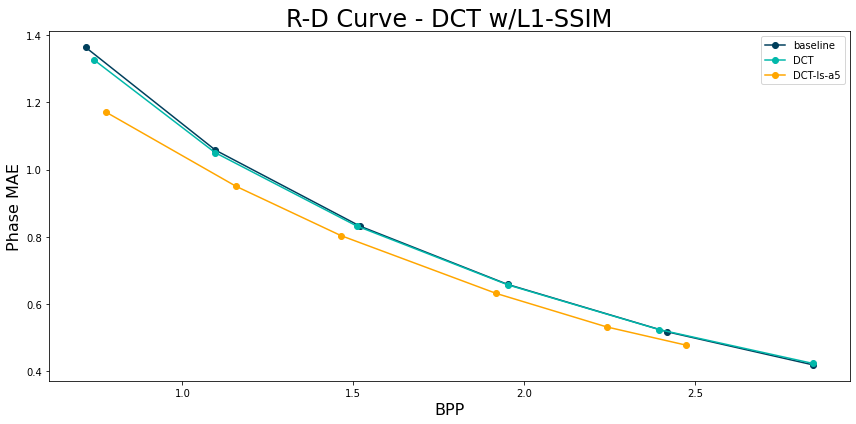

In [20]:
models = ["baseline", "DCT", "DCT-ls-a5"]
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ["#003f5c", "#01b8aa", "#ffa600"]

for i, model in enumerate(models):
    exp_data = results_df[results_df["model"] == model]
    ax.plot(exp_data["bpp"], exp_data["mae_phase"], label=model, marker="o", color=colors[i])
    ax.set_xlabel("BPP", fontsize=16)
    ax.set_ylabel("Phase MAE", fontsize=16)
    ax.set_title("R-D Curve - DCT w/L1-SSIM", fontsize=24)
    ax.legend()

plt.tight_layout()
plt.show()

# Analysis of Tokens

Normalized SAR Image:
-- Shape: torch.Size([1, 2, 256, 256]) | Range: [0.0000, 1.0000]
DCT Tokens:
-- Shape: torch.Size([1, 32, 64, 64]) | Range: [-1.1140, 2.9335]


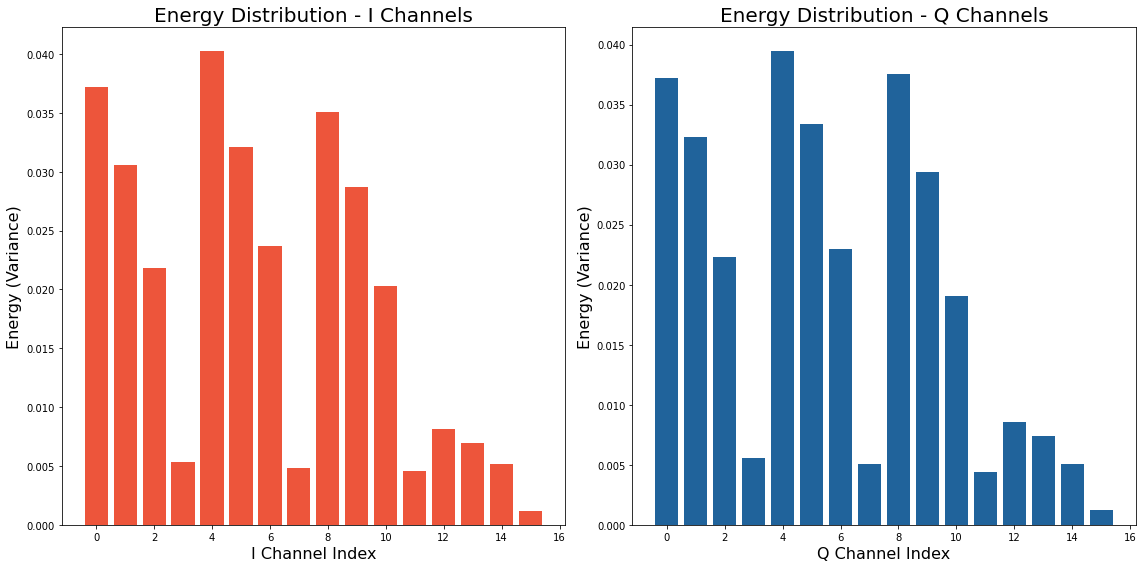

In [30]:
from src.utils.dct import ImageDCT
from test import load_image

inp = "/scratch/zb7df/data/NGA/multi_pol/validation/gt_HH/0.npy"
block = 4

img = load_image(inp)
dct_util = ImageDCT(block_size=block)
dc_ac = dct_util.dct_2d(img)

print("Normalized SAR Image:")
print(f"-- Shape: {img.shape} | Range: [{img.min().item():.4f}, {img.max().item():.4f}]")
print("DCT Tokens:")
print(f"-- Shape: {dc_ac.shape} | Range: [{dc_ac.min().item():.4f}, {dc_ac.max().item():.4f}]")

# Take variance across spatial dimensions for each channel
channel_energy = dc_ac.var(dim=[2, 3])
channel_energy_I = channel_energy[:, :16]
channel_energy_Q = channel_energy[:, 16:]

# # Plot energy distribution across I channels
# plt.figure(figsize=(12, 6))
# plt.bar(range(channel_energy.shape[1]), channel_energy[0].cpu().numpy(), color="#ed553b")
# plt.xlabel("Channel Index", fontsize=16)
# plt.ylabel("Energy (Variance)", fontsize=16)
# plt.title("Energy Distribution Across DCT Channels", fontsize=24)
# plt.tight_layout()
# plt.show()

# Plot energy distributions for I and Q channels in subplots
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.bar(range(channel_energy_I.shape[1]), channel_energy_I[0].cpu().numpy(), color="#ed553b")
plt.xlabel("I Channel Index", fontsize=16)
plt.ylabel("Energy (Variance)", fontsize=16)
plt.title("Energy Distribution - I Channels", fontsize=20)
plt.subplot(1, 2, 2)
plt.bar(range(channel_energy_Q.shape[1]), channel_energy_Q[0].cpu().numpy(), color="#20639b")
plt.xlabel("Q Channel Index", fontsize=16)
plt.ylabel("Energy (Variance)", fontsize=16)
plt.title("Energy Distribution - Q Channels", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
k = 8
in_channels = 32
out_channels = 64

energy_df = pd.DataFrame({"channel": list(range(channel_energy.shape[1])), "energy": channel_energy.flatten()})
energy_df = energy_df.sort_values(by="energy", ascending=False).reset_index(drop=True)
energy_df["energy_prop"] = energy_df["energy"] / energy_df["energy"].sum()

conn = k * out_channels
conn_adj = conn - (k * in_channels)
energy_df["connections"] = (energy_df["energy_prop"] * conn)
energy_df["connections_int"] = energy_df["connections"].round().astype(int)
energy_df["connections_adj"] = (energy_df["energy_prop"] * conn_adj) + k
energy_df["connections_adj_int"] = energy_df["connections_adj"].round().astype(int)
energy_df.loc[0, "connections_adj_int"] = energy_df.loc[0, "connections_adj_int"] - (energy_df["connections_adj_int"].sum() - conn)

print(energy_df["connections_int"].sum())
print(energy_df["connections_adj_int"].sum())
energy_df

# min 4

512
512


,channel,energy,energy_prop,connections,connections_int,connections_adj,connections_adj_int
0,4,0.040253,0.065273,33.419853,33,24.709927,26
1,20,0.039462,0.063991,32.763226,33,24.381613,24
2,24,0.037534,0.060865,31.162998,31,23.581499,24
3,16,0.037230,0.060371,30.909962,31,23.454981,23
4,0,0.037220,0.060355,30.901646,31,23.450823,23
5,8,0.035111,0.056935,29.150715,29,22.575357,23
6,21,0.033365,0.054105,27.701591,28,21.850796,22
7,17,0.032327,0.052420,26.839205,27,21.419601,21
8,5,0.032079,0.052019,26.633577,27,21.316788,21
9,1,0.030548,0.049536,25.362358,25,20.681179,21


## Plot Amp Image

torch.Size([1024, 1024])


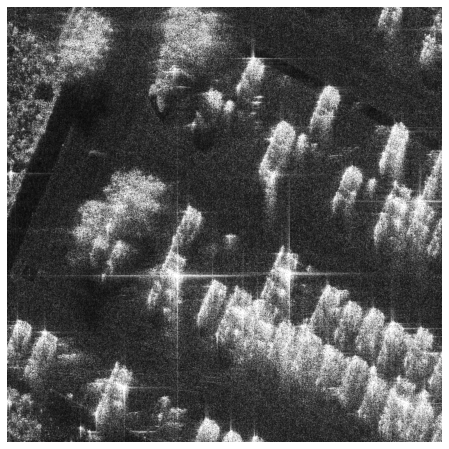

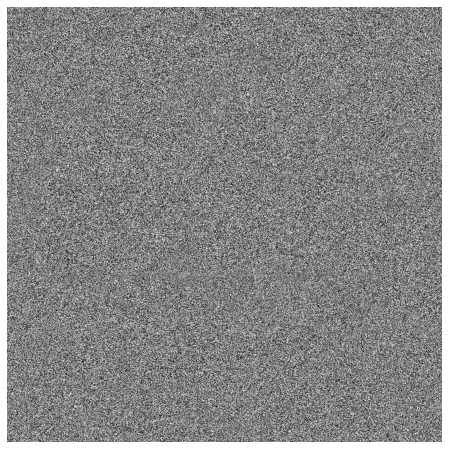

torch.Size([1024, 1024])


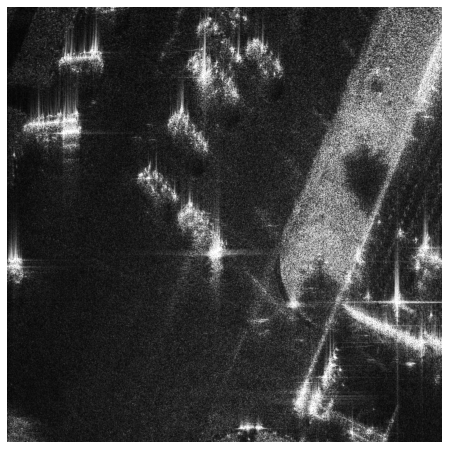

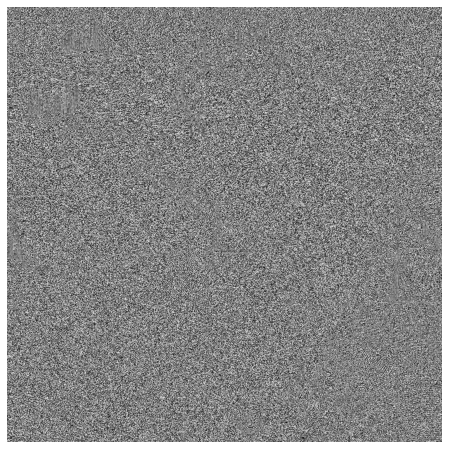

In [6]:
# Convert I/Q into Amplitude and display
import torch


def load_image(path):
    img_np = np.load(path)
    img_tensor = torch.from_numpy(img_np).float()
    return img_tensor


def iq_to_ap(iq):
    I = iq[:, :, 0]
    Q = iq[:, :, 1]
    amp = torch.sqrt(I**2 + Q**2)
    phase = torch.atan2(Q, I)
    return amp, phase


paths = ["/scratch/zb7df/data/NGA/multi_pol/test/gt_HH/0.npy",
         "/scratch/zb7df/data/NGA/multi_pol/test2/gt_HH/0.npy"]
for path in paths:
    img = load_image(path)
    amp, phase = iq_to_ap(img)
    print(amp.shape)

    plt.figure(figsize=(8, 8))
    plt.imshow(amp.cpu().numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(8, 8))
    plt.imshow(phase.cpu().numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

In [2]:
import shutil
from pathlib import Path

base_src = Path("/scratch/zb7df/data/NGA/multi_pol/train/")
base_dst = Path("/scratch/zb7df/data/NGA/multi_pol/train_val/")

for pol in ["gt_HH", "gt_HV", "gt_VH", "gt_VV"]:
    src = base_src / pol
    dst = base_dst / pol
    dst.mkdir(parents=True, exist_ok=True)
    for f in src.glob("*.npy"):
        if int(f.stem) % 10 == 0:
            shutil.move(f, dst / f.name)

In [37]:
logdir = "/scratch/zb7df/checkpoints/AHT_DCT"
dest = "/home/zb7df/dev/AHT_DCT/training_logs"

for folder in os.listdir(logdir):
    folder_path = os.path.join(logdir, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.startswith("events.out.tfevents"):
                src_file = os.path.join(folder_path, file)
                os.makedirs(os.path.join(dest, folder), exist_ok=True)
                dest_file = os.path.join(dest, f"{folder}/{file}")
                shutil.copy(src_file, dest_file)
                print(f"Copied {src_file} to {dest_file}")

Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT-exp2_lmbda0.025_20260127/events.out.tfevents.1769494055.kc-sse-ml-rn04.329343.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT-exp2_lmbda0.025_20260127/events.out.tfevents.1769494055.kc-sse-ml-rn04.329343.0
Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454850.kc-sse-ml-rn04.4054197.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454850.kc-sse-ml-rn04.4054197.0
Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454492.kc-sse-ml-rn04.4050119.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT_lmbda0.0035_20260126/events.out.tfevents.1769454492.kc-sse-ml-rn04.4050119.0
Copied /scratch/zb7df/checkpoints/AHT_DCT/AHT_DCT_uneven_lmbda0.0067_20260128/events.out.tfevents.1769661596.kc-sse-ml-rn04.1082873.0 to /home/zb7df/dev/AHT_DCT/training_logs/AHT_DCT_uneven_lmbda0.0067_20260128/events.out.tfevents.1769

In [ ]:
# orig = (x * 10000) - 5000
# orig = torch.sqrt(torch.sum(orig ** 2, dim=1, keepdim=True))
# orig_amp_db = 20 * torch.log10(orig_amp + 1e-6)
# orig = orig.squeeze().cpu().numpy()
# vmin, vmax = np.percentile(orig_amp, [0, 100])
# print(orig_amp.shape)
# plt.imshow(orig_amp, cmap='gray', vmin=vmin, vmax=vmax)
# plt.show()